# __Análisis del dataset limpiado:__

In [1]:
import pandas as pd 
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

carpeta_salida_figuras = Path("../Outputs/Figures")
carpeta_salida_figuras.mkdir(parents=True, exist_ok=True)

carpeta_salida_tablas = Path("../Outputs/Tables")
carpeta_salida_tablas.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None) # Maximiza la cantidad de columnas que muestra el dataframe
pd.set_option("display.max_rows", None) # Maximiza la cantidad de filas que muestra el dataframe
pd.set_option("display.max_colwidth", None) # Maximiza la cantidad de información que muestran las celdas del dataframe

df = pd.read_csv(r"../Data/processed/Caracteristicas y composicion del hogar - Filtrado.csv"
                 , sep=",") 
df.head(5)

,Es_Jefe_de_hogar,Edad,Estado_civil,Autorreconocimiento_etnico,Satisfaccion_vida,Satisfaccion_ingreso,Satisfaccion_salud,Satisfaccion_seguridad,Satisfaccion_trabajo,Satisfaccion_tiempo_libre,Sentido_proposito,Escalon_de_la_vida,Autorreconocimiento_sexual
0,1,45,Soltero/a,Ningún grupo,8.0,99.0,10.0,10.0,5.0,7.0,7.0,6.0,Mujer
1,2,25,Separado/Divorciado,Ningún grupo,10.0,8.0,10.0,10.0,8.0,7.0,8.0,8.0,Hombre
2,1,62,Viudo/a,Ningún grupo,5.0,4.0,7.0,7.0,4.0,7.0,8.0,7.0,Mujer
3,1,38,Union libre hace 2 años o más,Ningún grupo,8.0,8.0,8.0,5.0,8.0,8.0,8.0,8.0,Mujer
4,2,49,Union libre hace 2 años o más,Ningún grupo,8.0,9.0,8.0,5.0,8.0,8.0,8.0,8.0,Hombre


-----

# __Crear las columnas de bienestar:__

In [2]:
# Crear la columnas de bienestar emocional en base a las demás columnas promediadas con el mismo peso
columnas_bienestar_emocional = ["Satisfaccion_vida",
                               "Sentido_proposito",
                               "Escalon_de_la_vida",
                               "Satisfaccion_tiempo_libre"
                               ]
df["Bienestar_emocional"] = df[columnas_bienestar_emocional].mean(axis=1).round(2)

# Crear la columnas de bienestar material en base a las demás columnas promediadas con el mismo peso evadiendo los valores = 99 convirtíendolos a NaN
columnas_bienestar_material = ["Satisfaccion_seguridad",
                               "Satisfaccion_trabajo",
                               "Satisfaccion_salud",
                               "Satisfaccion_ingreso"
                               ]
df["Bienestar_material"] = df[columnas_bienestar_material].replace(99, np.nan).mean(axis=1).round(2)

# Crear la columnas de bienestar general en base a las columnas de bienestar emocional y material promediadas 
columnas_bienestar_general = ["Bienestar_material", "Bienestar_emocional"]
df["Bienestar_general"] = df[columnas_bienestar_general].mean(axis=1).round(2)

df.head(10)

,Es_Jefe_de_hogar,Edad,Estado_civil,Autorreconocimiento_etnico,Satisfaccion_vida,Satisfaccion_ingreso,Satisfaccion_salud,Satisfaccion_seguridad,Satisfaccion_trabajo,Satisfaccion_tiempo_libre,Sentido_proposito,Escalon_de_la_vida,Autorreconocimiento_sexual,Bienestar_emocional,Bienestar_material,Bienestar_general
0,1,45,Soltero/a,Ningún grupo,8.0,99.0,10.0,10.0,5.0,7.0,7.0,6.0,Mujer,7.00,8.33,7.66
1,2,25,Separado/Divorciado,Ningún grupo,10.0,8.0,10.0,10.0,8.0,7.0,8.0,8.0,Hombre,8.25,9.00,8.62
2,1,62,Viudo/a,Ningún grupo,5.0,4.0,7.0,7.0,4.0,7.0,8.0,7.0,Mujer,6.75,5.50,6.12
3,1,38,Union libre hace 2 años o más,Ningún grupo,8.0,8.0,8.0,5.0,8.0,8.0,8.0,8.0,Mujer,8.00,7.25,7.62
4,2,49,Union libre hace 2 años o más,Ningún grupo,8.0,9.0,8.0,5.0,8.0,8.0,8.0,8.0,Hombre,8.00,7.50,7.75
5,2,62,Viudo/a,Ningún grupo,8.0,8.0,7.0,5.0,5.0,7.0,8.0,8.0,Mujer,7.75,6.25,7.00
6,1,74,Viudo/a,Afrocolombiano,7.0,1.0,2.0,3.0,1.0,7.0,9.0,3.0,Mujer,6.50,1.75,4.12
7,2,93,Viudo/a,Ningún grupo,9.0,99.0,0.0,1.0,0.0,10.0,9.0,1.0,Hombre,7.25,0.33,3.79
8,2,43,Soltero/a,Ningún grupo,7.0,0.0,2.0,8.0,1.0,7.0,2.0,8.0,Hombre,6.00,2.75,4.38
9,1,63,Casado/a,Ningún grupo,8.0,7.0,8.0,7.0,7.0,8.0,10.0,8.0,Mujer,8.50,7.25,7.88


---

# __Análisis Descriptivo:__

---

## __Autorreconocimiento etnico:__

In [3]:
df["Autorreconocimiento_etnico"].value_counts()

Autorreconocimiento_etnico
Ningún grupo      139159
Indígena           18594
Afrocolombiano     13499
Raizal               690
Palenquero            58
Gitano/a (Rom)        25
Name: count, dtype: int64

In [4]:
df["Autorreconocimiento_etnico"].value_counts(normalize=True)*100

Autorreconocimiento_etnico
Ningún grupo      80.894637
Indígena          10.808894
Afrocolombiano     7.847115
Raizal             0.401104
Palenquero         0.033716
Gitano/a (Rom)     0.014533
Name: proportion, dtype: float64

In [5]:
df["Autorreconocimiento_etnico"].mode()

0    Ningún grupo
Name: Autorreconocimiento_etnico, dtype: str

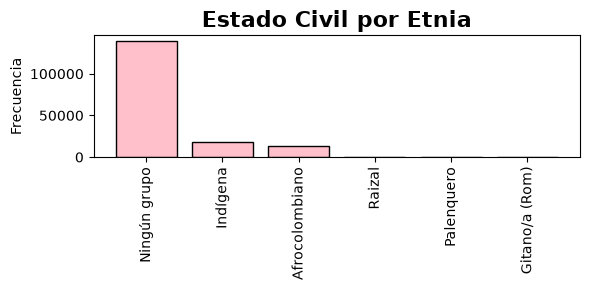

In [6]:
edad = df["Autorreconocimiento_etnico"].value_counts()

plt.figure(figsize=(6, 3))
plt.bar(edad.index, edad.values, color="pink", edgecolor="black")
plt.ylabel("Frecuencia")
plt.title("Estado Civil por Etnia", fontsize=16, fontweight="bold")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(carpeta_salida_figuras / "Frecuencia de estado civil por etnia.png", bbox_inches="tight", dpi=300)
plt.show()

---

## __Es jefe de hogar:__

In [7]:
df["Es_Jefe_de_hogar"].value_counts()

Es_Jefe_de_hogar
1    87754
2    84271
Name: count, dtype: int64

In [8]:
df["Es_Jefe_de_hogar"].value_counts(normalize=True)*100

Es_Jefe_de_hogar
1    51.012353
2    48.987647
Name: proportion, dtype: float64

In [9]:
df["Es_Jefe_de_hogar"].mode()

0    1
Name: Es_Jefe_de_hogar, dtype: int64

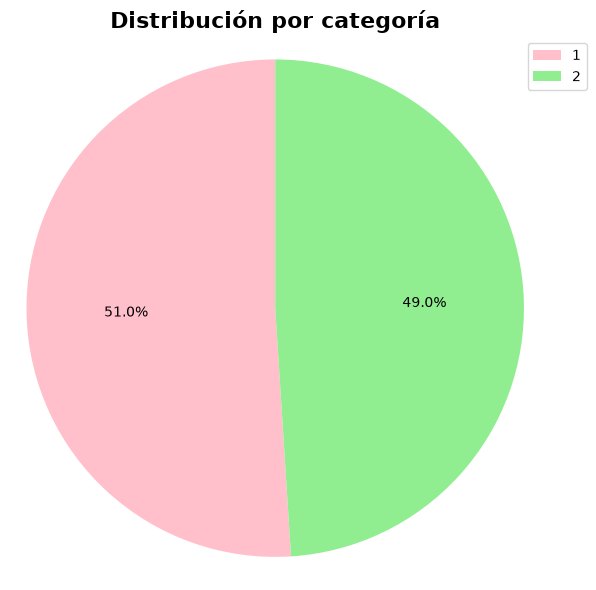

In [10]:
conteo = df["Es_Jefe_de_hogar"].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 6))
plt.pie(conteo.values, autopct="%1.1f%%", startangle=90, colors=["pink", "lightgreen"])
plt.title("Distribución por categoría", fontsize=16, fontweight="bold")
plt.legend(conteo.index, loc="best", bbox_to_anchor=(1.1, 1))
plt.axis("equal")
plt.tight_layout()
plt.savefig(carpeta_salida_figuras / "Distribucion es jefe del hogar GENERAL.png", bbox_inches="tight", dpi=300)
plt.show()

---

## __Estado civil:__

In [11]:
df["Estado_civil"].value_counts()

Estado_civil
Union libre hace 2 años o más       56869
Soltero/a                           42767
Casado/a                            35757
Separado/Divorciado                 22337
Viudo/a                             10644
Union libre hace menos de 2 años     3651
Name: count, dtype: int64

In [12]:
df["Estado_civil"].value_counts(normalize=True)*100

Estado_civil
Union libre hace 2 años o más       33.058567
Soltero/a                           24.860921
Casado/a                            20.785932
Separado/Divorciado                 12.984741
Viudo/a                              6.187473
Union libre hace menos de 2 años     2.122366
Name: proportion, dtype: float64

In [13]:
df["Estado_civil"].mode()

0    Union libre hace 2 años o más
Name: Estado_civil, dtype: str

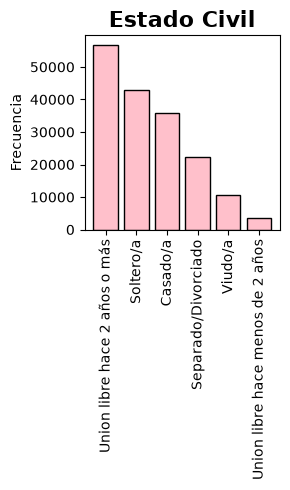

In [14]:
conteo = df["Estado_civil"].value_counts()

plt.figure(figsize=(3, 5))
plt.bar(conteo.index, conteo.values, color="pink", edgecolor="black")
plt.ylabel("Frecuencia")
plt.title("Estado Civil", fontsize=16, fontweight="bold")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(carpeta_salida_figuras / "Frecuencia estado civil GENERAL.png", bbox_inches="tight", dpi=300)
plt.show()

---

## __Autoreconocimiento sexual:__

In [15]:
df["Autorreconocimiento_sexual"].value_counts()

Autorreconocimiento_sexual
Mujer           90916
Hombre          80867
No responde       188
Hombre trans       26
Otro               14
Mujer trans        14
Name: count, dtype: int64

In [16]:
df["Autorreconocimiento_sexual"].value_counts(normalize=True)*100

Autorreconocimiento_sexual
Mujer           52.850458
Hombre          47.008865
No responde      0.109286
Hombre trans     0.015114
Otro             0.008138
Mujer trans      0.008138
Name: proportion, dtype: float64

In [17]:
df["Autorreconocimiento_sexual"].mode()

0    Mujer
Name: Autorreconocimiento_sexual, dtype: str

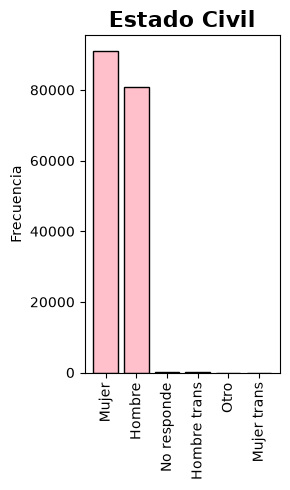

In [18]:
conteo = df["Autorreconocimiento_sexual"].value_counts()

plt.figure(figsize=(3, 5))
plt.bar(conteo.index, conteo.values, color="pink", edgecolor="black")
plt.ylabel("Frecuencia")
plt.title("Estado Civil", fontsize=16, fontweight="bold")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(carpeta_salida_figuras / "Frecuencia autorreconocimiento sexual GENERAL.png", bbox_inches="tight", dpi=300)
plt.show()

---

## __Edad:__

In [19]:
df["Edad"].mode()

0    30
Name: Edad, dtype: int64

In [20]:
df["Edad"].median()

np.float64(44.0)

In [21]:
df["Edad"].mean()

np.float64(45.84404592355762)

In [22]:
df["Edad"].std()

np.float64(17.972662002448217)

In [23]:
df["Edad"].var()

np.float64(323.0165794542459)

In [24]:
df["Edad"].std()

np.float64(17.972662002448217)

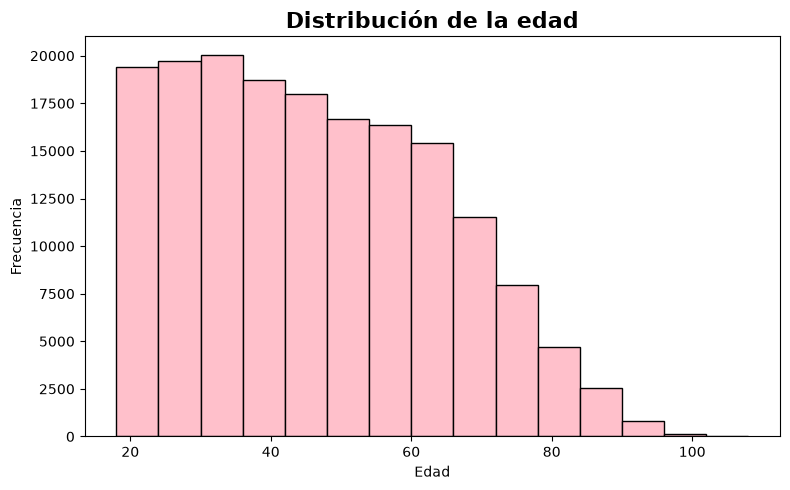

In [25]:
edad = df["Edad"].value_counts()

plt.figure(figsize=(8, 5))
plt.hist(df["Edad"], bins=15, color="pink", edgecolor="black")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.title("Distribución de la edad", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(carpeta_salida_figuras / "Distribucion edad GENERAL.png", bbox_inches="tight", dpi=300)
plt.show()

---

## __Satisfacción Salud:__

In [26]:
df["Satisfaccion_salud"].mode()

0    8.0
Name: Satisfaccion_salud, dtype: float64

In [27]:
df["Satisfaccion_salud"].median()

np.float64(8.0)

In [28]:
df["Satisfaccion_salud"].mean()

np.float64(7.83912803371603)

In [29]:
df["Satisfaccion_salud"].std()

np.float64(1.8737689989399118)

In [30]:
df["Satisfaccion_salud"].value_counts(normalize=True)*100

Satisfaccion_salud
8.0     25.940416
10.0    22.081093
9.0     17.056823
7.0     14.911786
6.0      8.437146
5.0      6.304316
4.0      2.400814
3.0      1.445720
2.0      0.673158
0.0      0.495277
1.0      0.253452
Name: proportion, dtype: float64

In [31]:
df["Satisfaccion_salud"].value_counts()

Satisfaccion_salud
8.0     44624
10.0    37985
9.0     29342
7.0     25652
6.0     14514
5.0     10845
4.0      4130
3.0      2487
2.0      1158
0.0       852
1.0       436
Name: count, dtype: int64

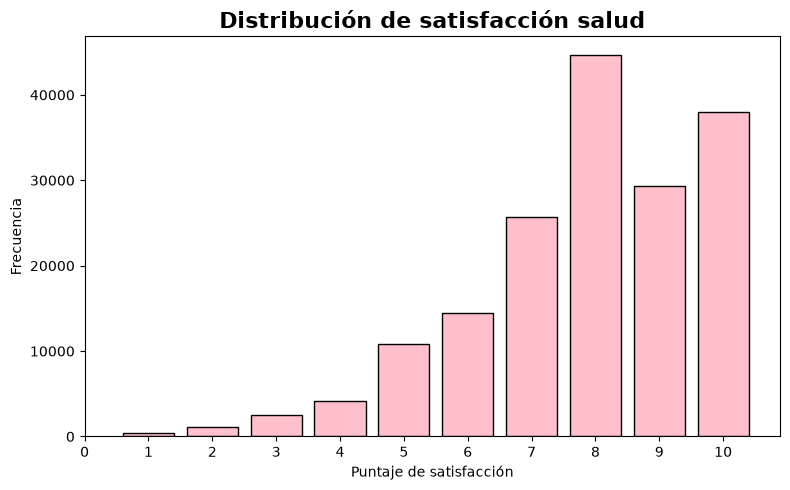

In [32]:
conteo = df["Satisfaccion_salud"].value_counts().reindex(range(1, 11), fill_value=0)

plt.figure(figsize=(8, 5))
plt.bar(conteo.index, conteo.values, color="pink", edgecolor="black")
plt.xlabel("Puntaje de satisfacción")
plt.ylabel("Frecuencia")
plt.title("Distribución de satisfacción salud", fontsize=16, fontweight="bold")
plt.xticks(range(0, 11))
plt.tight_layout()
plt.savefig(carpeta_salida_figuras / "Distribución satisfaccion salud GENERAL.png", bbox_inches="tight", dpi=300)
plt.show()

---

## __Satisfacción trabajo:__

In [33]:
df["Satisfaccion_trabajo"].mode()

0    8.0
Name: Satisfaccion_trabajo, dtype: float64

In [34]:
df["Satisfaccion_trabajo"].median()

np.float64(8.0)

In [35]:
df["Satisfaccion_trabajo"].mean()

np.float64(7.354739136753379)

In [36]:
df["Satisfaccion_trabajo"].std()

np.float64(2.201838614209288)

In [37]:
df["Satisfaccion_trabajo"].value_counts()

Satisfaccion_trabajo
8.0     43386
10.0    30532
7.0     29089
9.0     21989
6.0     18072
5.0     13021
4.0      5244
3.0      3594
0.0      3368
2.0      2242
1.0      1488
Name: count, dtype: int64

In [38]:
df["Satisfaccion_trabajo"].value_counts(normalize=True)*100

Satisfaccion_trabajo
8.0     25.220753
10.0    17.748583
7.0     16.909751
9.0     12.782444
6.0     10.505450
5.0      7.569249
4.0      3.048394
3.0      2.089231
0.0      1.957855
2.0      1.303299
1.0      0.864991
Name: proportion, dtype: float64

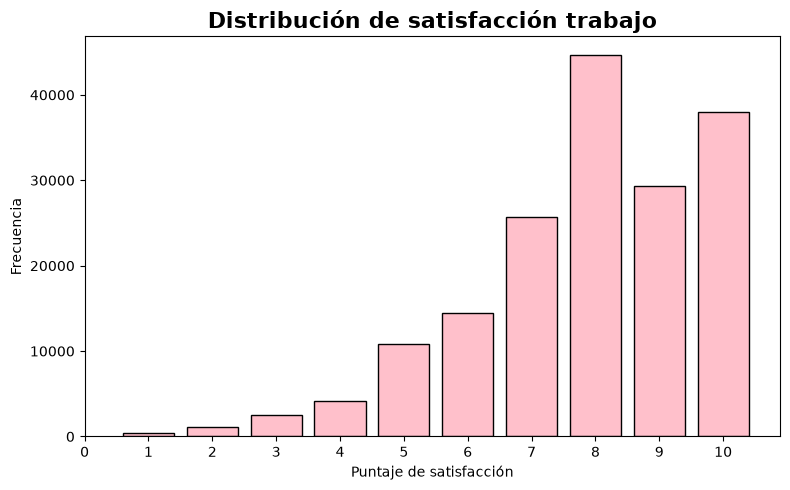

In [39]:
conteo = df["Satisfaccion_salud"].value_counts().reindex(range(1, 11), fill_value=0)

plt.figure(figsize=(8, 5))
plt.bar(conteo.index, conteo.values, color="pink", edgecolor="black")
plt.xlabel("Puntaje de satisfacción")
plt.ylabel("Frecuencia")
plt.title("Distribución de satisfacción trabajo", fontsize=16, fontweight="bold")
plt.xticks(range(0, 11))
plt.tight_layout()
plt.savefig(carpeta_salida_figuras / "Distribucion satisfaccion trabajo GENERAL.png", bbox_inches="tight", dpi=300)
plt.show()

---

## __Satisfacción vida:__

In [40]:
df["Satisfaccion_vida"].mode()

0    8.0
Name: Satisfaccion_vida, dtype: float64

In [41]:
df["Satisfaccion_vida"].median()

np.float64(8.0)

In [42]:
df["Satisfaccion_vida"].mean()

np.float64(8.142223514024124)

In [43]:
df["Satisfaccion_vida"].std()

np.float64(1.6346435321501112)

In [44]:
df["Satisfaccion_vida"].value_counts()

Satisfaccion_vida
8.0     50090
10.0    42294
9.0     31968
7.0     24693
6.0     11226
5.0      7138
4.0      2112
3.0      1200
2.0       571
0.0       526
1.0       207
Name: count, dtype: int64

In [45]:
df["Satisfaccion_vida"].value_counts(normalize=True)*100

Satisfaccion_vida
8.0     29.117861
10.0    24.585961
9.0     18.583345
7.0     14.354309
6.0      6.525796
5.0      4.149397
4.0      1.227729
3.0      0.697573
2.0      0.331928
0.0      0.305770
1.0      0.120331
Name: proportion, dtype: float64

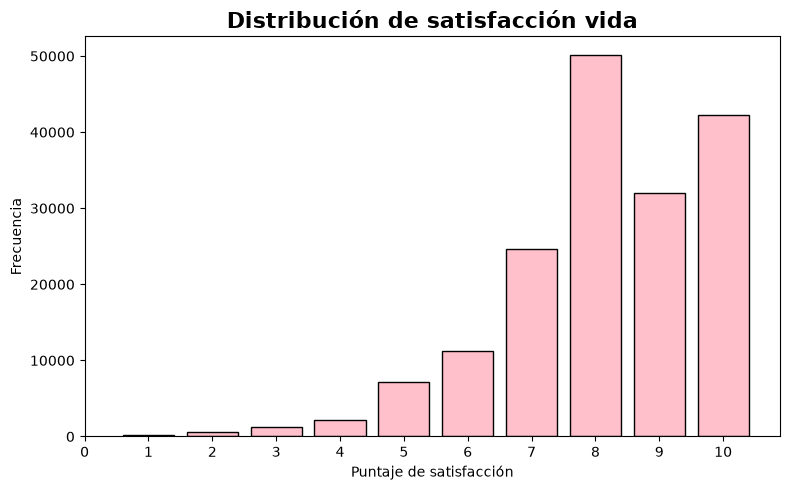

In [46]:
conteo = df["Satisfaccion_vida"].value_counts().reindex(range(1, 11), fill_value=0)

plt.figure(figsize=(8, 5))
plt.bar(conteo.index, conteo.values, color="pink", edgecolor="black")
plt.xlabel("Puntaje de satisfacción")
plt.ylabel("Frecuencia")
plt.title("Distribución de satisfacción vida", fontsize=16, fontweight="bold")
plt.xticks(range(0, 11))
plt.tight_layout()
plt.savefig(carpeta_salida_figuras / "Distribucion satisfaccion vida GENERAL.png", bbox_inches="tight", dpi=300)
plt.show()

---

## __Satisfaccion_ingreso:__ 

In [47]:
df["Satisfaccion_ingreso"].mode()

0    8.0
Name: Satisfaccion_ingreso, dtype: float64

In [48]:
df["Satisfaccion_ingreso"].median()

np.float64(7.0)

In [49]:
df["Satisfaccion_ingreso"].mean()

np.float64(18.29915419270455)

In [50]:
df["Satisfaccion_ingreso"].std()

np.float64(30.725714484303502)

In [51]:
df["Satisfaccion_ingreso"].value_counts()

Satisfaccion_ingreso
8.0     30799
7.0     25626
99.0    21681
6.0     19081
10.0    17703
5.0     17386
9.0     14440
4.0      8694
3.0      7044
2.0      4521
0.0      2687
1.0      2363
Name: count, dtype: int64

In [52]:
df["Satisfaccion_ingreso"].value_counts(normalize=True)*100

Satisfaccion_ingreso
8.0     17.903793
7.0     14.896672
99.0    12.603401
6.0     11.091992
10.0    10.290946
5.0     10.106671
9.0      8.394129
4.0      5.053917
3.0      4.094754
2.0      2.628106
0.0      1.561982
1.0      1.373638
Name: proportion, dtype: float64

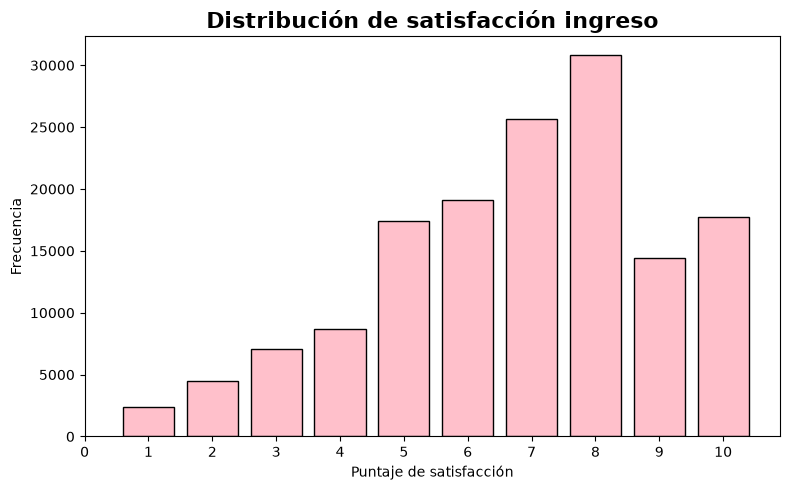

In [53]:
conteo = df["Satisfaccion_ingreso"].value_counts().reindex(range(1, 11), fill_value=0)

plt.figure(figsize=(8, 5))
plt.bar(conteo.index, conteo.values, color="pink", edgecolor="black")
plt.xlabel("Puntaje de satisfacción")
plt.ylabel("Frecuencia")
plt.title("Distribución de satisfacción ingreso", fontsize=16, fontweight="bold")
plt.xticks(range(0, 11))
plt.tight_layout()
plt.savefig(carpeta_salida_figuras / "Distribucion satisfaccion ingreso GENERAL.png", bbox_inches="tight", dpi=300)
plt.show()

---

## __Satisfaccion seguridad:__

In [54]:
df["Satisfaccion_seguridad"].median()

np.float64(8.0)

In [55]:
df["Satisfaccion_seguridad"].mode()

0    8.0
Name: Satisfaccion_seguridad, dtype: float64

In [56]:
df["Satisfaccion_seguridad"].mean()

np.float64(7.759564016858015)

In [57]:
df["Satisfaccion_seguridad"].std()

np.float64(1.9482628365781354)

In [58]:
df["Satisfaccion_seguridad"].value_counts()

Satisfaccion_seguridad
8.0     43277
10.0    37248
9.0     28057
7.0     26857
6.0     15496
5.0     10891
4.0      4205
3.0      2675
2.0      1373
0.0      1337
1.0       609
Name: count, dtype: int64

In [59]:
df["Satisfaccion_seguridad"].value_counts(normalize=True)*100

Satisfaccion_seguridad
8.0     25.157390
10.0    21.652667
9.0     16.309839
7.0     15.612266
6.0      9.007993
5.0      6.331057
4.0      2.444412
3.0      1.555007
2.0      0.798140
0.0      0.777213
1.0      0.354018
Name: proportion, dtype: float64

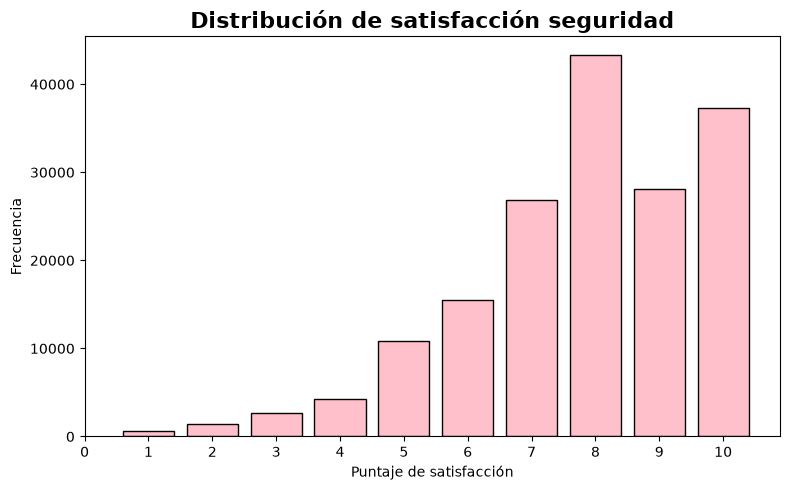

In [60]:
conteo = df["Satisfaccion_seguridad"].value_counts().reindex(range(1, 11), fill_value=0)

plt.figure(figsize=(8, 5))
plt.bar(conteo.index, conteo.values, color="pink", edgecolor="black")
plt.xlabel("Puntaje de satisfacción")
plt.ylabel("Frecuencia")
plt.title("Distribución de satisfacción seguridad", fontsize=16, fontweight="bold")
plt.xticks(range(0, 11))
plt.tight_layout()
plt.savefig(carpeta_salida_figuras / "Distribucion satisfaccion seguridad GENERAL.png", bbox_inches="tight", dpi=300)
plt.show()

---

## __Satisfacción tiempo libre:__

In [61]:
df["Satisfaccion_tiempo_libre"].median()

np.float64(8.0)

In [62]:
df["Satisfaccion_tiempo_libre"].mode()

0    8.0
Name: Satisfaccion_tiempo_libre, dtype: float64

In [63]:
df["Satisfaccion_tiempo_libre"].mean()

np.float64(7.585781136462724)

In [64]:
df["Satisfaccion_tiempo_libre"].std()

np.float64(1.9096129245905233)

In [65]:
df["Satisfaccion_tiempo_libre"].value_counts()


Satisfaccion_tiempo_libre
8.0     44660
10.0    33615
7.0     30426
9.0     21187
6.0     18374
5.0     12844
4.0      5124
3.0      3224
2.0      1392
0.0       746
1.0       433
Name: count, dtype: int64

In [66]:
df["Satisfaccion_tiempo_libre"].value_counts(normalize=True)*100


Satisfaccion_tiempo_libre
8.0     25.961343
10.0    19.540764
7.0     17.686964
9.0     12.316233
6.0     10.681006
5.0      7.466357
4.0      2.978637
3.0      1.874146
2.0      0.809185
0.0      0.433658
1.0      0.251708
Name: proportion, dtype: float64

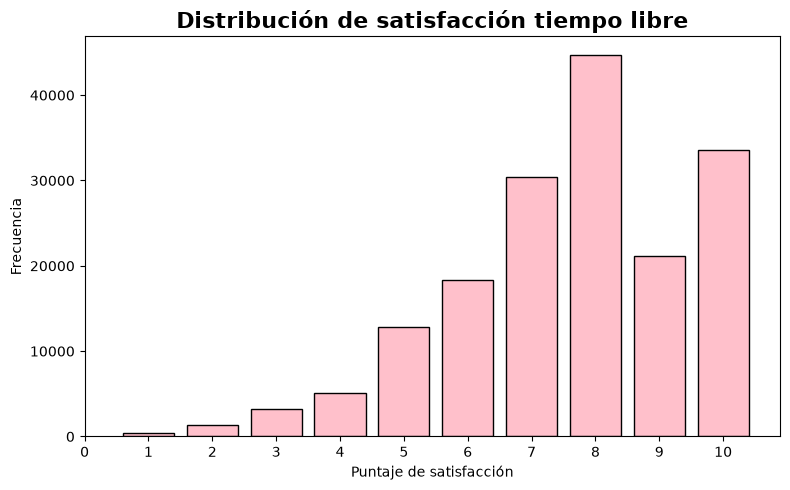

In [67]:
conteo = df["Satisfaccion_tiempo_libre"].value_counts().reindex(range(1, 11), fill_value=0)

plt.figure(figsize=(8, 5))
plt.bar(conteo.index, conteo.values, color="pink", edgecolor="black")
plt.xlabel("Puntaje de satisfacción")
plt.ylabel("Frecuencia")
plt.title("Distribución de satisfacción tiempo libre", fontsize=16, fontweight="bold")
plt.xticks(range(0, 11))
plt.tight_layout()
plt.savefig(carpeta_salida_figuras / "Distribucion satisfaccion tiempo libre GENERAL.png", bbox_inches="tight", dpi=300)
plt.show()

---

## __Sentido proposito:__

In [68]:
df["Sentido_proposito"].mean()

np.float64(8.550513006830403)

In [69]:
df["Sentido_proposito"].mode()

0    10.0
Name: Sentido_proposito, dtype: float64

In [70]:
df["Sentido_proposito"].median()

np.float64(9.0)

In [71]:
df["Sentido_proposito"].std()

np.float64(1.6204440553704054)

In [72]:
df["Sentido_proposito"].value_counts()

Sentido_proposito
10.0    67687
8.0     38414
9.0     29582
7.0     19143
6.0      8576
5.0      4788
4.0      1767
3.0       940
2.0       482
0.0       413
1.0       233
Name: count, dtype: int64

In [73]:
df["Sentido_proposito"].value_counts(normalize=True)*1000

Sentido_proposito
10.0    393.471879
8.0     223.304752
9.0     171.963377
7.0     111.280337
6.0      49.853219
5.0      27.833164
4.0      10.271763
3.0       5.464322
2.0       2.801918
0.0       2.400814
1.0       1.354454
Name: proportion, dtype: float64

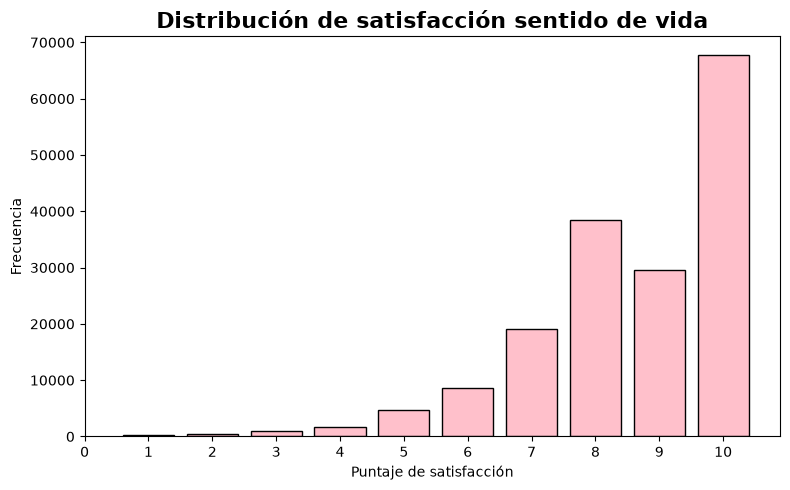

In [74]:
conteo = df["Sentido_proposito"].value_counts().reindex(range(1, 11), fill_value=0)

plt.figure(figsize=(8, 5))
plt.bar(conteo.index, conteo.values, color="pink", edgecolor="black")
plt.xlabel("Puntaje de satisfacción")
plt.ylabel("Frecuencia")
plt.title("Distribución de satisfacción sentido de vida", fontsize=16, fontweight="bold")
plt.xticks(range(0, 11))
plt.tight_layout()
plt.savefig(carpeta_salida_figuras / "Distribucion satisfaccion sentido proposito GENERAL.png", bbox_inches="tight", dpi=300)
plt.show()

---

## Escalon de la vida

In [75]:
df["Escalon_de_la_vida"].std()

np.float64(1.6808054910406514)

In [76]:
df["Escalon_de_la_vida"].mean()

np.float64(7.655358232814998)

In [77]:
df["Escalon_de_la_vida"].mode()

0    8.0
Name: Escalon_de_la_vida, dtype: float64

In [78]:
df["Escalon_de_la_vida"].median()

np.float64(8.0)

In [79]:
df["Escalon_de_la_vida"].value_counts()

Escalon_de_la_vida
8.0     49567
7.0     34943
10.0    27073
9.0     24142
6.0     18504
5.0     11116
4.0      3605
3.0      1729
2.0       644
0.0       433
1.0       269
Name: count, dtype: int64

In [80]:
df["Escalon_de_la_vida"].value_counts(normalize=True)*1000

Escalon_de_la_vida
8.0     288.138352
7.0     203.127452
10.0    157.378288
9.0     140.340067
6.0     107.565761
5.0      64.618515
4.0      20.956256
3.0      10.050865
2.0       3.743642
0.0       2.517076
1.0       1.563726
Name: proportion, dtype: float64

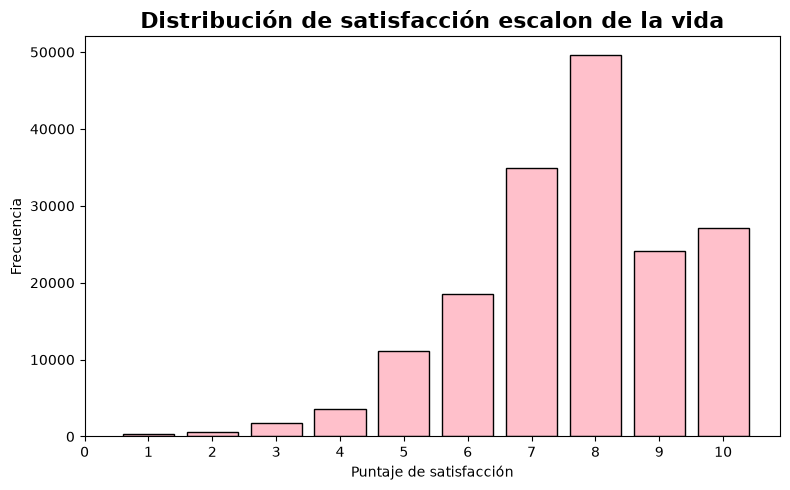

In [81]:
conteo = df["Escalon_de_la_vida"].value_counts().reindex(range(1, 11), fill_value=0)

plt.figure(figsize=(8, 5))
plt.bar(conteo.index, conteo.values, color="pink", edgecolor="black")
plt.xlabel("Puntaje de satisfacción")
plt.ylabel("Frecuencia")
plt.title("Distribución de satisfacción escalon de la vida", fontsize=16, fontweight="bold")
plt.xticks(range(0, 11))
plt.tight_layout()
plt.savefig(carpeta_salida_figuras / "Distribucion satisfaccion escalon de la vida GENERAL.png", bbox_inches="tight", dpi=300)
plt.show()

---

## __Bienestar emocional:__

In [82]:
df["Bienestar_emocional"].mean()

np.float64(7.983468972533062)

In [83]:
df["Bienestar_emocional"].median()

np.float64(8.0)

In [84]:
df["Bienestar_emocional"].std()

np.float64(1.339756244463485)

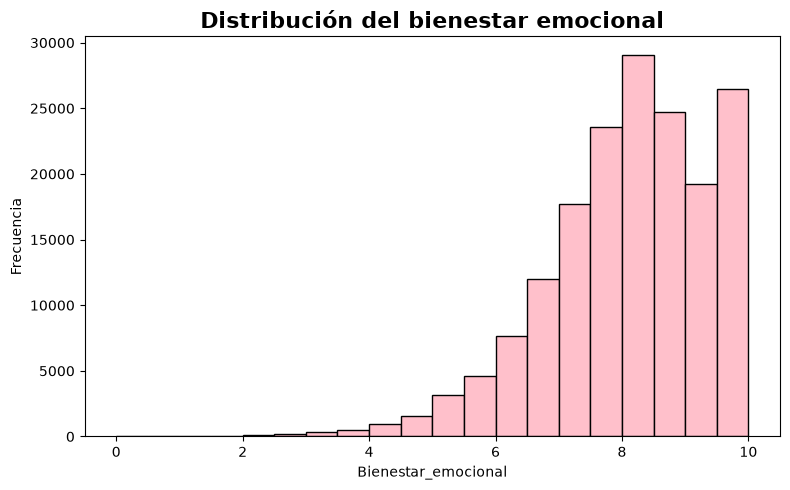

In [85]:
conteo = df["Bienestar_emocional"].value_counts()

plt.figure(figsize=(8, 5))
plt.hist(df["Bienestar_emocional"], bins=20, color="pink", edgecolor="black")
plt.xlabel("Bienestar_emocional")
plt.ylabel("Frecuencia")
plt.title("Distribución del bienestar emocional", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(carpeta_salida_figuras / "Distribucion bienestar emocional GENERAL.png", bbox_inches="tight", dpi=300)
plt.show()

---

## __Bienestar material:__

In [86]:
df["Bienestar_material"].mean()

np.float64(7.426450806568813)

In [87]:
df["Bienestar_material"].median()

np.float64(7.5)

In [88]:
df["Bienestar_material"].std()

np.float64(1.6158691777707521)

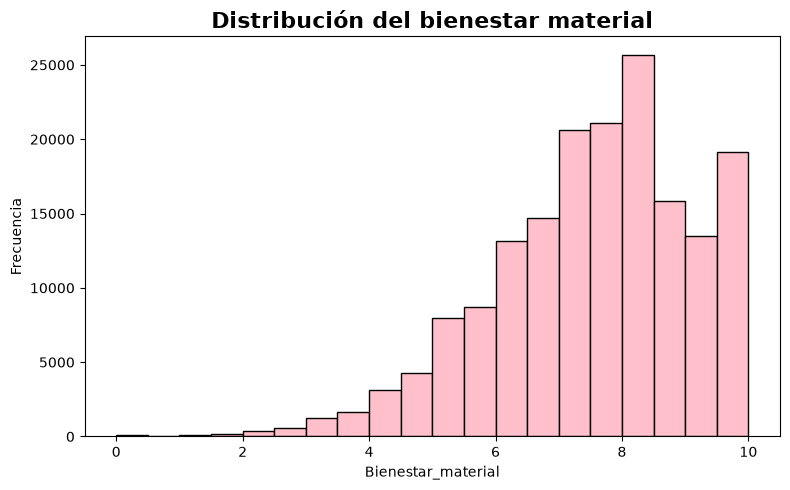

In [89]:
conteo = df["Bienestar_material"].value_counts()

plt.figure(figsize=(8, 5))
plt.hist(df["Bienestar_material"], bins=20, color="pink", edgecolor="black") 
plt.xlabel("Bienestar_material")
plt.ylabel("Frecuencia")
plt.title("Distribución del bienestar material", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(carpeta_salida_figuras / "Distribucion bienestar material GENERAL.png", bbox_inches="tight", dpi=300)
plt.show()

---

## __Bienestar general:__

In [90]:
df["Bienestar_general"].std()

np.float64(1.3734974025374576)

In [91]:
df["Bienestar_general"].mean()

np.float64(7.704998168870804)

In [92]:
df["Bienestar_general"].median()

np.float64(7.88)

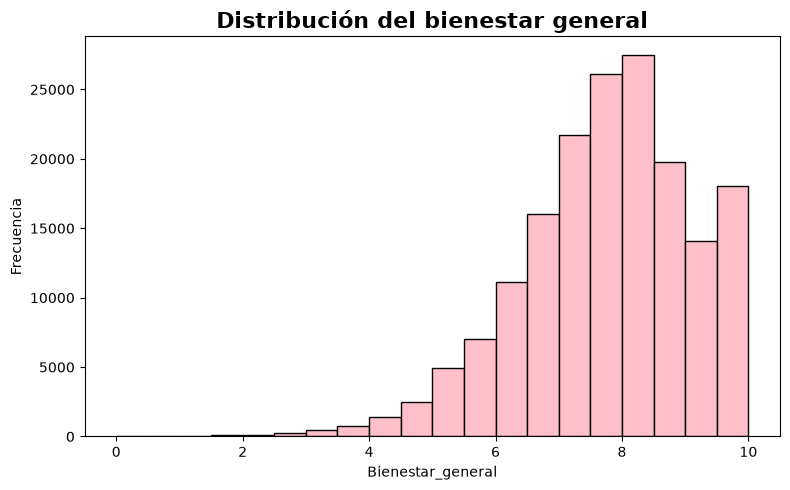

In [93]:
conteo = df["Bienestar_general"].value_counts()

plt.figure(figsize=(8, 5))
plt.hist(df["Bienestar_general"], bins=20, color="pink", edgecolor="black")
plt.xlabel("Bienestar_general")
plt.ylabel("Frecuencia")
plt.title("Distribución del bienestar general", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(carpeta_salida_figuras / "Distribucion bienestar general GENERAL.png", bbox_inches="tight", dpi=300)
plt.show()

---

# __Promedio de Bienestares por etnia:__

In [94]:
df.groupby("Autorreconocimiento_etnico").agg({"Bienestar_emocional":"mean", "Bienestar_material":"mean", "Bienestar_general":"mean"}).round(2)

,Bienestar_emocional,Bienestar_material,Bienestar_general
Autorreconocimiento_etnico,,,
Afrocolombiano,7.64,6.81,7.23
Gitano/a (Rom),8.01,7.64,7.82
Indígena,7.67,7.17,7.42
Ningún grupo,8.05,7.51,7.78
Palenquero,7.88,7.48,7.68
Raizal,8.64,8.48,8.56


----

# __Correlaciones iniciales:__

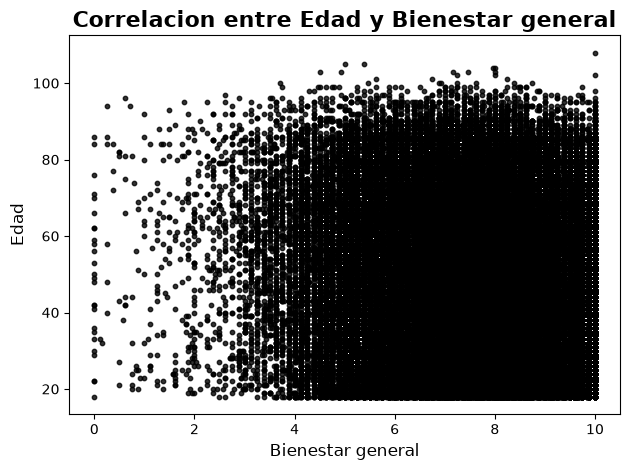

In [95]:
df_scatter = df.copy()
df_scatter.plot.scatter(x="Bienestar_general",y="Edad", color="black",s=10, alpha=0.8,)
plt.title("Correlacion entre Edad y Bienestar general", fontsize=16, fontweight="bold")
plt.xlabel("Bienestar general", fontsize=12)
plt.ylabel("Edad", fontsize=12)
plt.tight_layout()
plt.savefig(carpeta_salida_figuras / "correlacion_entre_edad_y_bienestar_general.png", bbox_inches="tight", dpi=300)
plt.show()

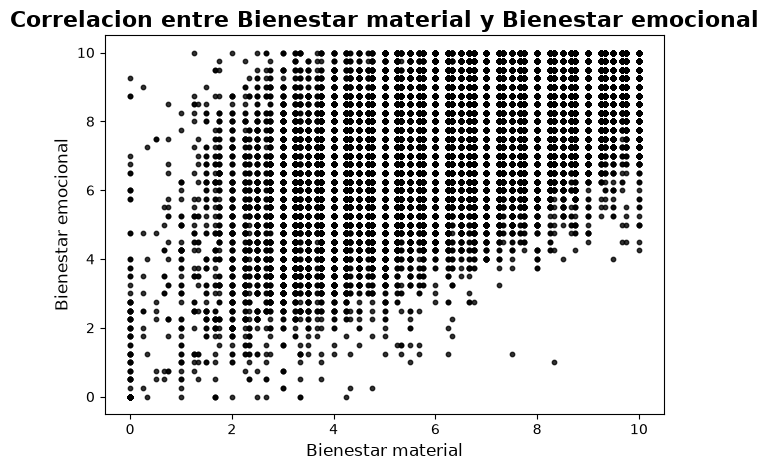

In [96]:
df_scatter_material_emocional = df.copy()
df_scatter_material_emocional.plot.scatter(x="Bienestar_material",y="Bienestar_emocional", color="black",s=10, alpha=0.8,)
plt.title("Correlacion entre Bienestar material y Bienestar emocional", fontsize=16, fontweight="bold")
plt.xlabel("Bienestar material", fontsize=12)
plt.ylabel("Bienestar emocional", fontsize=12)
plt.tight_layout()
plt.savefig(carpeta_salida_figuras / "correlacion_entre_bienestar_material_y_bienestar_emocional.png", bbox_inches="tight", dpi=300)
plt.show()

In [97]:
df[["Bienestar_material", "Bienestar_emocional"]].corr()

,Bienestar_material,Bienestar_emocional
Bienestar_material,1.000000,0.725121
Bienestar_emocional,0.725121,1.000000


---

## __Matríz de correlación:__

In [98]:
variables = ["Satisfaccion_vida", "Satisfaccion_ingreso", "Satisfaccion_salud", "Satisfaccion_seguridad", "Satisfaccion_trabajo", "Satisfaccion_tiempo_libre",
             "Sentido_proposito", "Escalon_de_la_vida"]

In [99]:
df[variables].corr().round(2)

,Satisfaccion_vida,Satisfaccion_ingreso,Satisfaccion_salud,Satisfaccion_seguridad,Satisfaccion_trabajo,Satisfaccion_tiempo_libre,Sentido_proposito,Escalon_de_la_vida
Satisfaccion_vida,1.00,0.02,0.56,0.44,0.50,0.49,0.53,0.54
Satisfaccion_ingreso,0.02,1.00,-0.01,0.04,-0.08,0.06,0.02,-0.00
Satisfaccion_salud,0.56,-0.01,1.00,0.44,0.48,0.44,0.45,0.45
Satisfaccion_seguridad,0.44,0.04,0.44,1.00,0.42,0.45,0.36,0.38
Satisfaccion_trabajo,0.50,-0.08,0.48,0.42,1.00,0.50,0.39,0.45
Satisfaccion_tiempo_libre,0.49,0.06,0.44,0.45,0.50,1.00,0.41,0.44
Sentido_proposito,0.53,0.02,0.45,0.36,0.39,0.41,1.00,0.50
Escalon_de_la_vida,0.54,-0.00,0.45,0.38,0.45,0.44,0.50,1.00


-------


# __Crear un sub-dataframe por cada etnia para realizar los análisis necesarios:__

In [100]:
df["Autorreconocimiento_etnico"].value_counts()

Autorreconocimiento_etnico
Ningún grupo      139159
Indígena           18594
Afrocolombiano     13499
Raizal               690
Palenquero            58
Gitano/a (Rom)        25
Name: count, dtype: int64

In [101]:
df_ninguna_etnia = df[df["Autorreconocimiento_etnico"] == "Ningún grupo"]
df_afrocolombiano = df[df["Autorreconocimiento_etnico"] == "Afrocolombiano"]
df_indigena = df[df["Autorreconocimiento_etnico"] == "Indigena"]
df_raizal = df[df["Autorreconocimiento_etnico"] == "Raizal"]
df_palenquero = df[df["Autorreconocimiento_etnico"] == "Palenquero"]
df_gitano =  df[df["Autorreconocimiento_etnico"] == "Gitano/a (Rom)"]

-----

# __Correlacion por etnia entre estado civil y bienestar general:__

In [102]:
resumen_bienestar_estado_civil = df.groupby(["Autorreconocimiento_etnico", "Estado_civil"])["Bienestar_general"].mean().unstack().round(2)
resumen_bienestar_estado_civil

Estado_civil,Casado/a,Separado/Divorciado,Soltero/a,Union libre hace 2 años o más,Union libre hace menos de 2 años,Viudo/a
Autorreconocimiento_etnico,,,,,,
Afrocolombiano,7.43,7.08,7.26,7.24,7.30,6.90
Gitano/a (Rom),7.88,6.82,8.35,7.75,7.75,NaN
Indígena,7.63,7.36,7.50,7.35,7.74,7.20
Ningún grupo,7.88,7.71,7.78,7.82,7.87,7.45
Palenquero,8.81,7.24,7.40,7.83,8.75,7.17
Raizal,8.31,7.80,8.45,8.92,9.70,8.68


-----

# __Frecuencias de etnia y autorreconocimiento sexual:__

In [103]:
df_ninguna_etnia["Autorreconocimiento_sexual"].value_counts(normalize=True)*100

Autorreconocimiento_sexual
Mujer           52.815844
Hombre          47.039717
No responde      0.111383
Hombre trans     0.017246
Mujer trans      0.008623
Otro             0.007186
Name: proportion, dtype: float64

In [104]:
df_afrocolombiano["Autorreconocimiento_sexual"].value_counts(normalize=True)*100

Autorreconocimiento_sexual
Mujer           53.818801
Hombre          46.077487
No responde      0.059264
Otro             0.022224
Mujer trans      0.014816
Hombre trans     0.007408
Name: proportion, dtype: float64

In [105]:
df_indigena["Autorreconocimiento_sexual"].value_counts(normalize=True)*100

Series([], Name: proportion, dtype: float64)

In [106]:
df_raizal["Autorreconocimiento_sexual"].value_counts(normalize=True)*100

Autorreconocimiento_sexual
Mujer          53.913043
Hombre         45.942029
No responde     0.144928
Name: proportion, dtype: float64

In [107]:
df_palenquero["Autorreconocimiento_sexual"].value_counts(normalize=True)*100

Autorreconocimiento_sexual
Hombre    53.448276
Mujer     46.551724
Name: proportion, dtype: float64

In [108]:
df_gitano["Autorreconocimiento_sexual"].value_counts(normalize=True)*100

Autorreconocimiento_sexual
Mujer     60.0
Hombre    40.0
Name: proportion, dtype: float64

-----

# __Tendencia central de etnia y edad:__

In [109]:
resumen_edad = (df.groupby("Autorreconocimiento_etnico").agg(n=("Autorreconocimiento_etnico","count"),promedio_edad=("Edad","mean"),mediana_edad=("Edad","median"),moda_edad=("Edad",lambda x: x.mode())))
resumen_edad

,n,promedio_edad,mediana_edad,moda_edad
Autorreconocimiento_etnico,,,,
Afrocolombiano,13499,45.117268,43.0,18
Gitano/a (Rom),25,46.960000,46.0,"[25, 57]"
Indígena,18594,41.406421,38.0,25
Ningún grupo,139159,46.506140,45.0,30
Palenquero,58,47.155172,47.0,58
Raizal,690,45.965217,43.5,"[41, 61]"


---

## __Frecuencias de edad por étnia:__

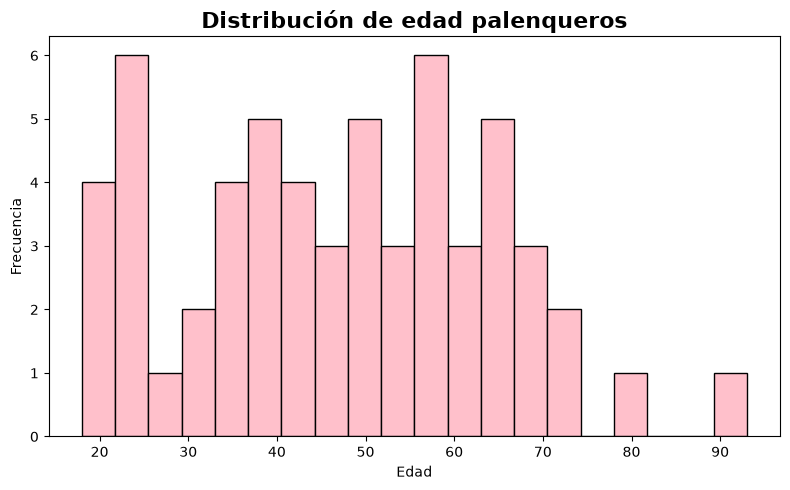

In [110]:
conteo = df_palenquero["Edad"].value_counts()

plt.figure(figsize=(8, 5))
plt.hist(df_palenquero["Edad"], bins=20, color="pink", edgecolor="black")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.title("Distribución de edad palenqueros", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(carpeta_salida_figuras / "Distribucion edad palenqueros.png", bbox_inches="tight", dpi=300)
plt.show()

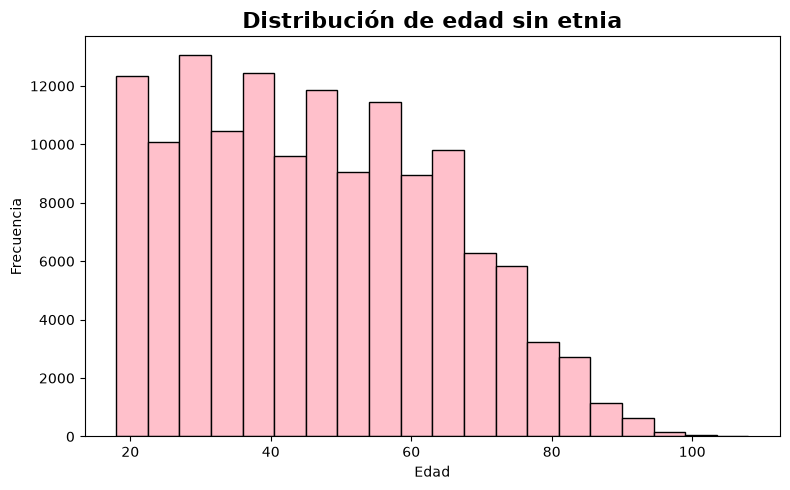

In [111]:
conteo = df_ninguna_etnia["Edad"].value_counts()

plt.figure(figsize=(8, 5))
plt.hist(df_ninguna_etnia["Edad"], bins=20, color="pink", edgecolor="black")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.title("Distribución de edad sin etnia", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(carpeta_salida_figuras / "Distribucion edad sin etnia.png", bbox_inches="tight", dpi=300)
plt.show()

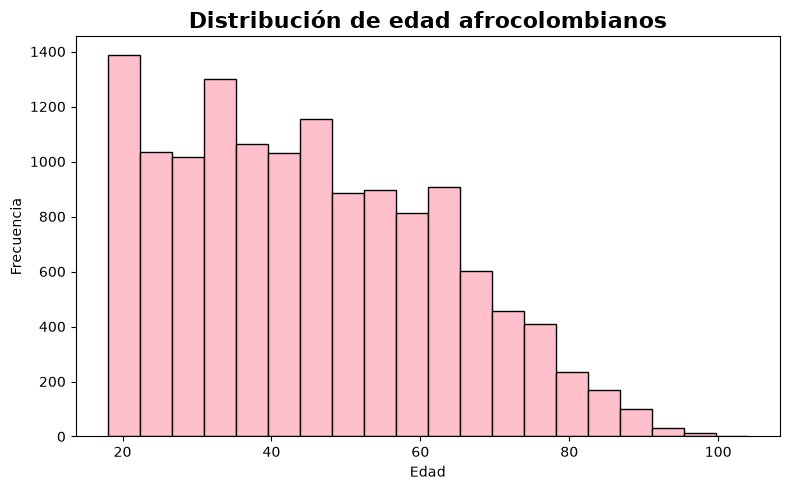

In [112]:
conteo = df_afrocolombiano["Edad"].value_counts()

plt.figure(figsize=(8, 5))
plt.hist(df_afrocolombiano["Edad"], bins=20, color="pink", edgecolor="black")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.title("Distribución de edad afrocolombianos", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(carpeta_salida_figuras / "Distribucion edad afrocolombianos.png", bbox_inches="tight", dpi=300)
plt.show()

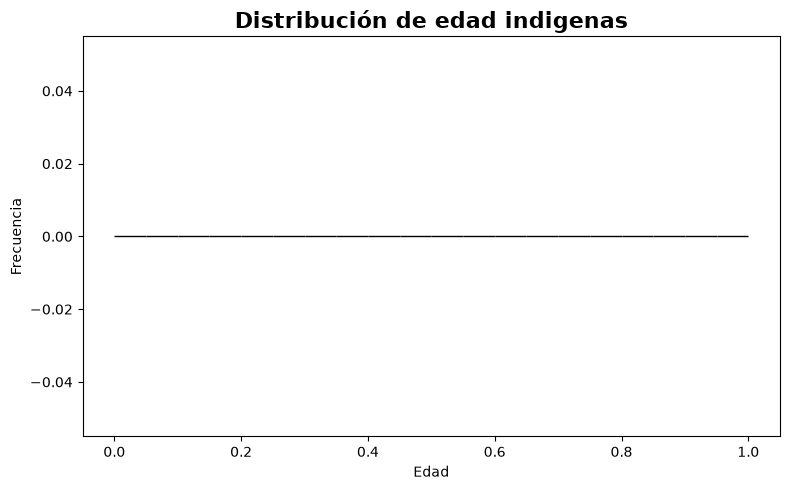

In [113]:
conteo = df_indigena["Edad"].value_counts()

plt.figure(figsize=(8, 5))
plt.hist(df_indigena["Edad"], bins=20, color="pink", edgecolor="black")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.title("Distribución de edad indigenas", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(carpeta_salida_figuras / "Distribucion edad indigenas.png", bbox_inches="tight", dpi=300)
plt.show()